<a href="https://colab.research.google.com/github/bittokjeff/Machine-Learning/blob/main/E_Commerce_Sales_Data_Analysis_99_Beats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
erfan4524_e_commerce_sales_data_analysis_and_eda_path = kagglehub.dataset_download('erfan4524/e-commerce-sales-data-analysis-and-eda')

print('Data source import complete.')


100%|██████████| 2.11M/2.11M [00:00<00:00, 48.5MB/s]

Extracting files...


Data source import complete.


# Importing

## Import Library

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

## Import CSV And convert to DataFrame

In [5]:
import os
df = pd.read_csv(os.path.join(erfan4524_e_commerce_sales_data_analysis_and_eda_path, 'clean_final_data.csv'))

# Preprocessing

## Frist five row

In [6]:
df.head()

,OrderID,CustomerID,OrderDate,ProductID,Quantity,Discount,PaymentMethod,Status,Age,City,SignupDate,CustomerSegment,ProductName,Category,UnitPrice,Sales,OrderValue
0,500001,103695,2025-08-28,2003,4.0,10.0,Gateway,Completed,36.0,Qom,2024-03-05,Regular,USB-C Cable,Accessories,9.0,32.0,32.0
1,500002,107935,2024-05-31,2014,1.0,10.0,Wallet,Completed,49.0,Kerman,2025-06-04,Regular,Backpack,Accessories,42.0,38.0,38.0
2,500003,105141,2025-08-10,2002,1.0,20.0,CardToCard,Completed,36.0,Tehran,2025-10-19,Regular,Mechanical Keyboard,Electronics,62.0,50.0,50.0
3,500004,108780,2024-10-11,2012,1.0,10.0,Gateway,Completed,45.0,Shiraz,2023-12-07,Regular,Office Chair,Home Office,180.0,162.0,162.0
4,500005,101187,2024-02-19,2008,2.0,0.0,Gateway,Completed,24.0,Karaj,2023-12-02,Regular,Phone Case,Accessories,14.0,28.0,28.0


##Last Five rows

In [7]:
df.tail()

,OrderID,CustomerID,OrderDate,ProductID,Quantity,Discount,PaymentMethod,Status,Age,City,SignupDate,CustomerSegment,ProductName,Category,UnitPrice,Sales,OrderValue
49217,549996,104649,2025-04-30,2013,2.0,5.0,CardToCard,Completed,32.0,Tehran,2025-03-24,Regular,Notebook,Stationery,7.0,13.0,13.0
49218,549997,108686,2025-01-26,2004,1.0,10.0,Gateway,Completed,45.0,Tehran,2024-03-08,New,Power Bank,Electronics,35.0,32.0,32.0
49219,549998,107639,2026-04-13,2010,1.0,0.0,Cash,Completed,56.0,Shiraz,2025-02-19,Regular,Fitness Band,Wearables,55.0,55.0,55.0
49220,549999,108215,2025-04-18,2005,1.0,0.0,CardToCard,Completed,20.0,Qom,2025-08-11,Regular,Laptop Stand,Accessories,28.0,28.0,28.0
49221,550000,102166,2024-04-06,2004,1.0,10.0,Wallet,Completed,62.0,Isfahan,2025-02-01,New,Power Bank,Electronics,35.0,32.0,32.0


## Shape of our dataset

In [8]:
df.shape

(49222, 17)

## List out all columns

In [9]:
df.columns

Index(['OrderID', 'CustomerID', 'OrderDate', 'ProductID', 'Quantity',
       'Discount', 'PaymentMethod', 'Status', 'Age', 'City', 'SignupDate',
       'CustomerSegment', 'ProductName', 'Category', 'UnitPrice', 'Sales',
       'OrderValue'],
      dtype='object')

## Datatype of each columns

In [10]:
df.dtypes

,0
OrderID,int64
CustomerID,int64
OrderDate,object
ProductID,int64
Quantity,float64
Discount,float64
PaymentMethod,object
Status,object
Age,float64
City,object


## Information of all Columns

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49222 entries, 0 to 49221
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          49222 non-null  int64  
 1   CustomerID       49222 non-null  int64  
 2   OrderDate        49222 non-null  object 
 3   ProductID        49222 non-null  int64  
 4   Quantity         49222 non-null  float64
 5   Discount         49222 non-null  float64
 6   PaymentMethod    49222 non-null  object 
 7   Status           49222 non-null  object 
 8   Age              49222 non-null  float64
 9   City             49222 non-null  object 
 10  SignupDate       49222 non-null  object 
 11  CustomerSegment  49222 non-null  object 
 12  ProductName      49222 non-null  object 
 13  Category         49222 non-null  object 
 14  UnitPrice        49222 non-null  float64
 15  Sales            49222 non-null  float64
 16  OrderValue       49222 non-null  float64
dtypes: float64(6

## Check Null Value

In [12]:
df.isnull().sum()

,0
OrderID,0
CustomerID,0
OrderDate,0
ProductID,0
Quantity,0
Discount,0
PaymentMethod,0
Status,0
Age,0
City,0


## Check Dupicate Value

In [13]:
df.duplicated().sum()

np.int64(0)

## Summary

In [14]:
df.describe()

,OrderID,CustomerID,ProductID,Quantity,Discount,Age,UnitPrice,Sales,OrderValue
count,49222.000000,49222.000000,49222.000000,49222.000000,49222.000000,49222.000000,49222.000000,49222.000000,49222.000000
mean,525007.608366,105002.304356,2009.460160,1.881923,7.485576,41.283369,40.286579,69.985576,69.985576
std,14435.345449,2888.912895,5.578603,1.079382,7.754378,13.681355,42.613062,94.483273,94.483273
min,500001.000000,100001.000000,2001.000000,-2.000000,0.000000,18.000000,7.000000,-170.000000,-170.000000
25%,512507.250000,102504.000000,2004.000000,1.000000,0.000000,29.000000,11.000000,17.000000,17.000000
50%,525016.500000,105005.000000,2008.000000,2.000000,5.000000,41.000000,28.000000,38.000000,38.000000
75%,537506.750000,107497.000000,2014.000000,2.000000,10.000000,53.000000,58.000000,84.000000,84.000000
max,550000.000000,110000.000000,2020.000000,5.000000,30.000000,65.000000,260.000000,1300.000000,1300.000000


# EDA

In [15]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

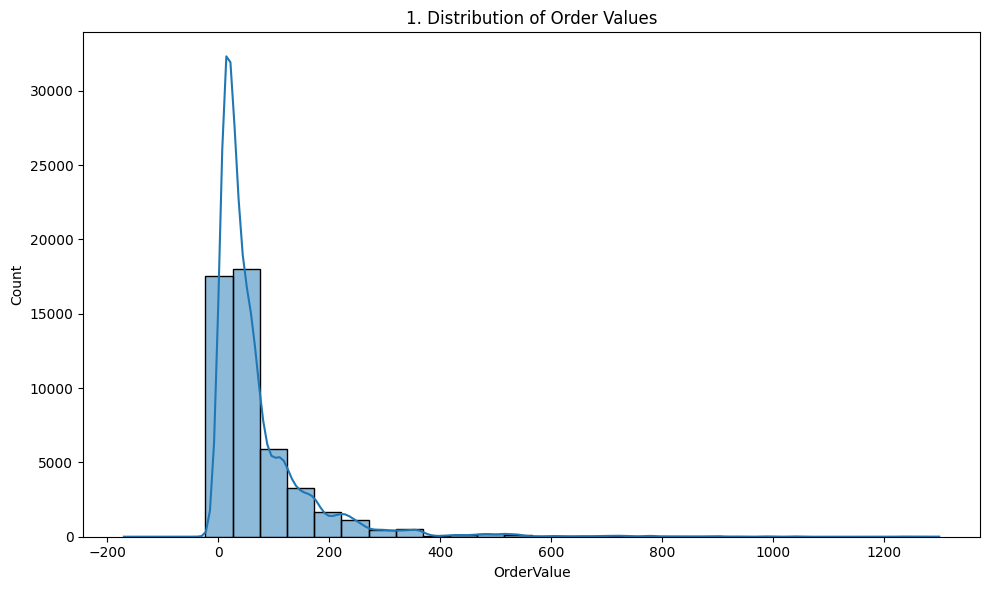

In [16]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['OrderValue'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Order Values')
show_fig()
plot_no += 1

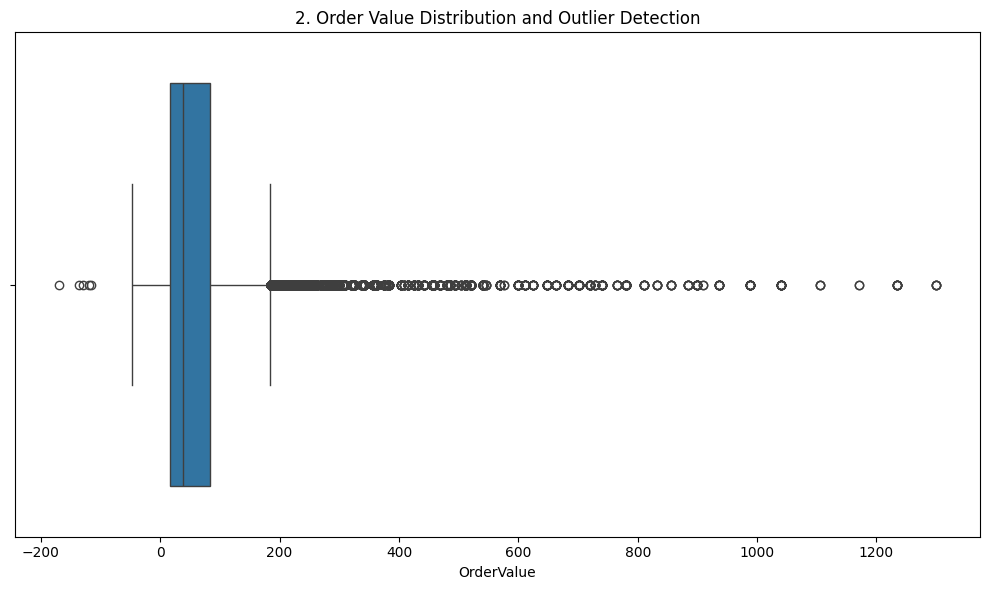

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x=df['OrderValue'])
plt.title(f'{plot_no}. Order Value Distribution and Outlier Detection')
show_fig()
plot_no += 1

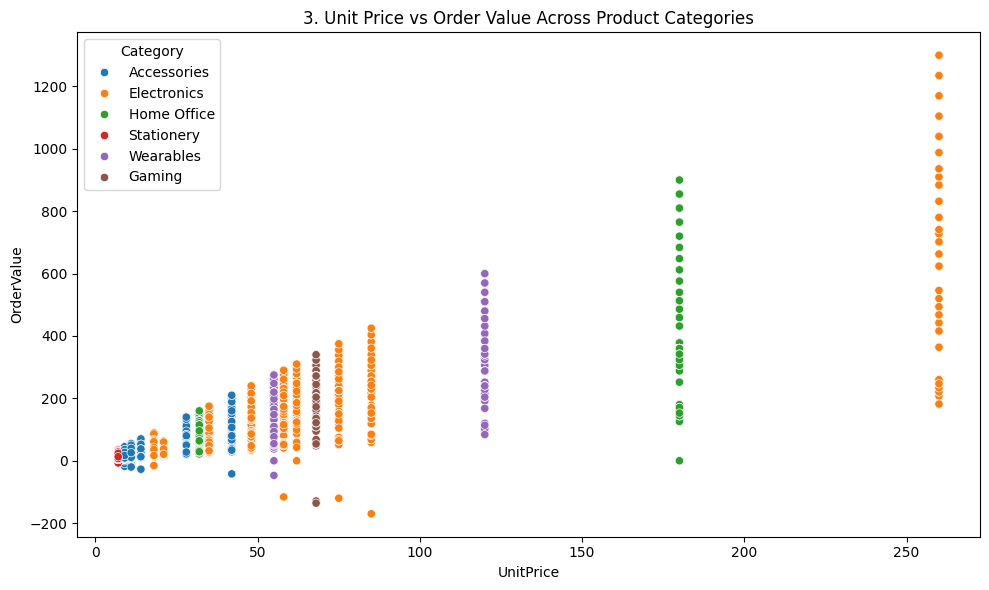

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='UnitPrice', y='OrderValue', hue='Category')
plt.title(f'{plot_no}. Unit Price vs Order Value Across Product Categories')
show_fig()
plot_no += 1

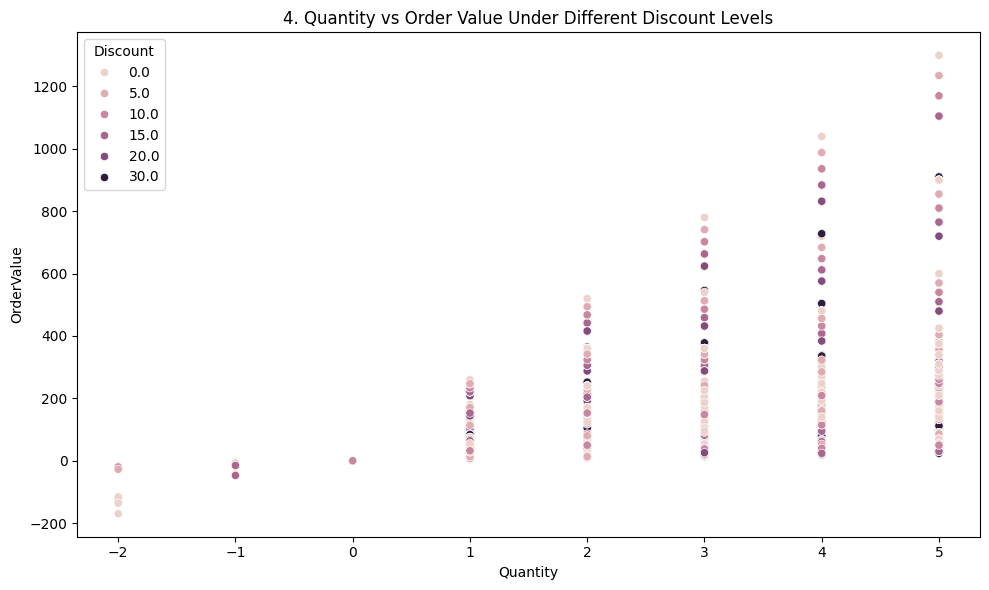

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Quantity', y='OrderValue', hue='Discount')
plt.title(f'{plot_no}. Quantity vs Order Value Under Different Discount Levels')
show_fig()
plot_no += 1

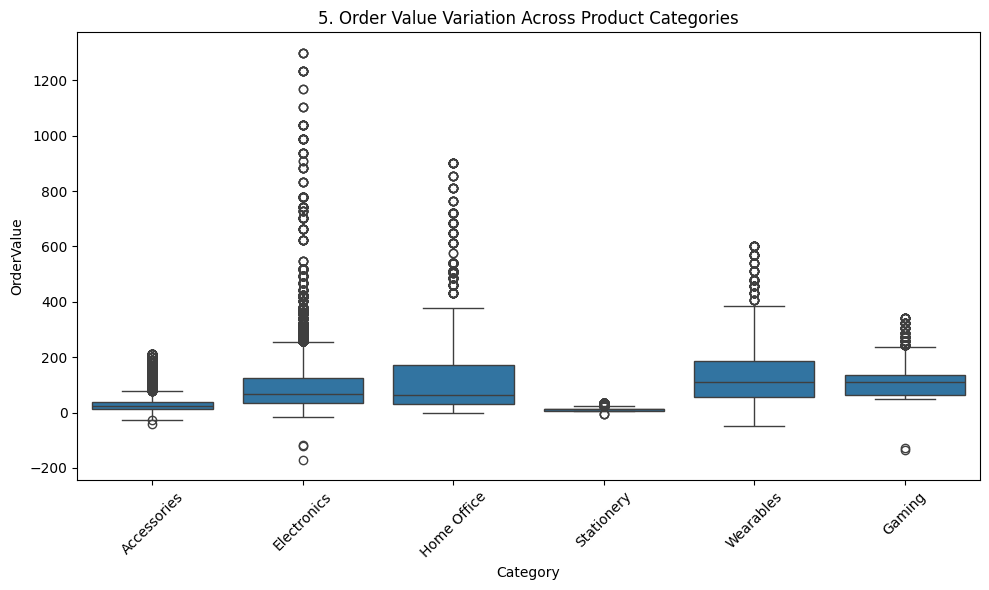

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Category', y='OrderValue')
plt.title(f'{plot_no}. Order Value Variation Across Product Categories')
plt.xticks(rotation=45)
show_fig()
plot_no += 1

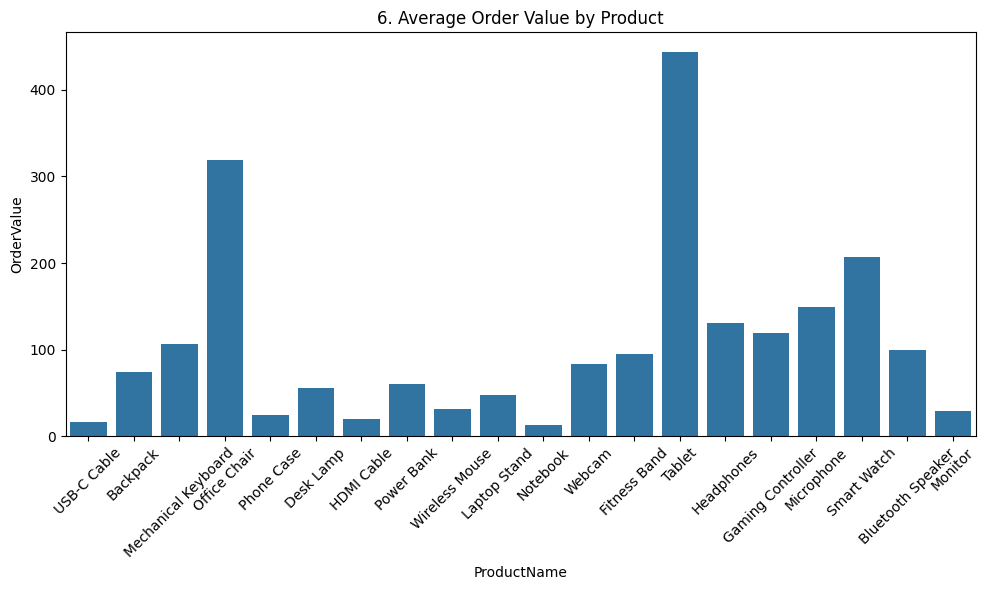

In [21]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='ProductName', y='OrderValue', estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Average Order Value by Product')
plt.xticks(rotation=45)
show_fig()
plot_no += 1

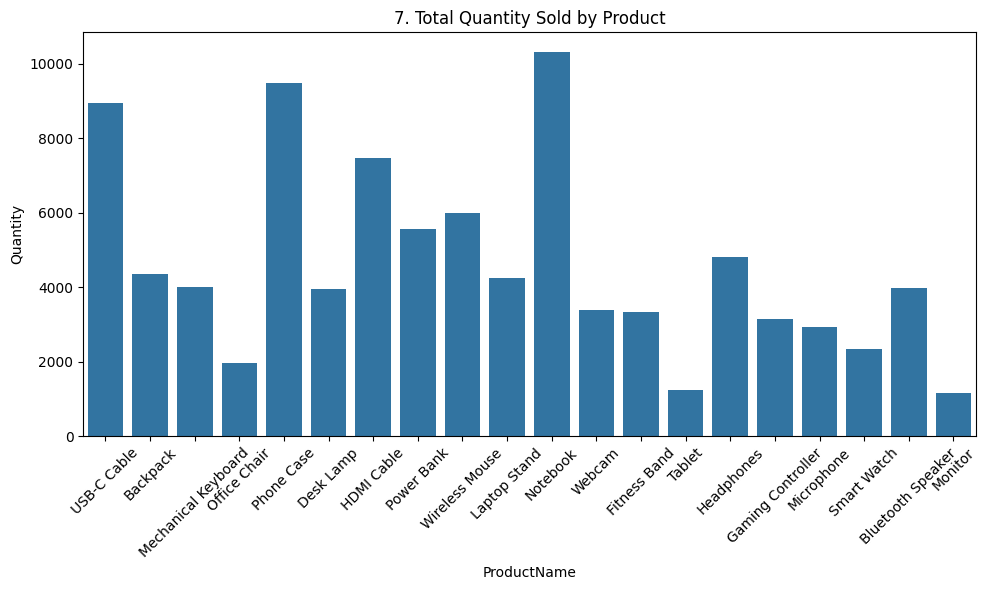

In [22]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='ProductName', y='Quantity', estimator='sum', errorbar=None)
plt.title(f'{plot_no}. Total Quantity Sold by Product')
plt.xticks(rotation=45)
show_fig()
plot_no += 1

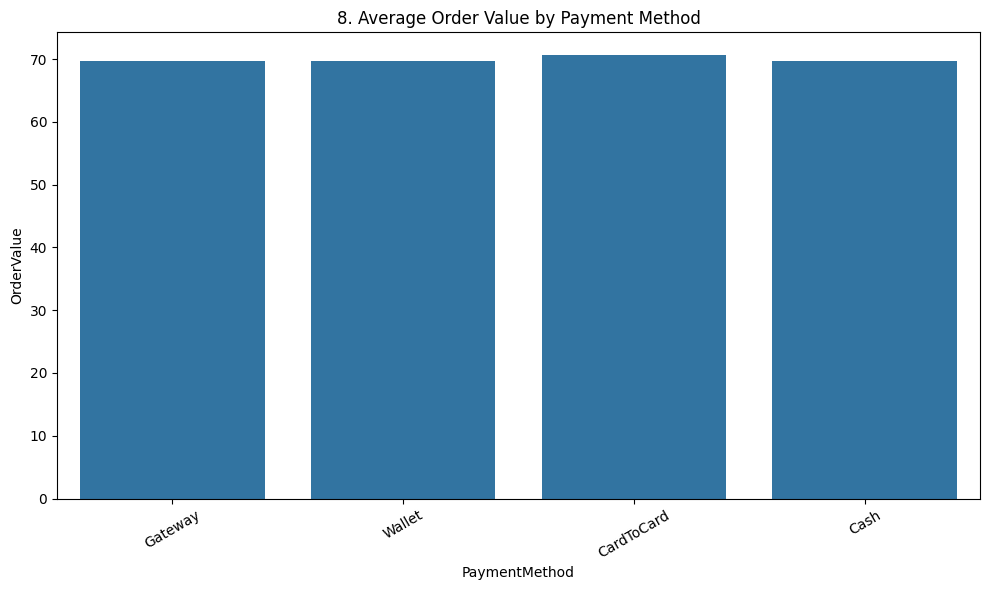

In [23]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='PaymentMethod', y='OrderValue', estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Average Order Value by Payment Method')
plt.xticks(rotation=30)
show_fig()
plot_no += 1

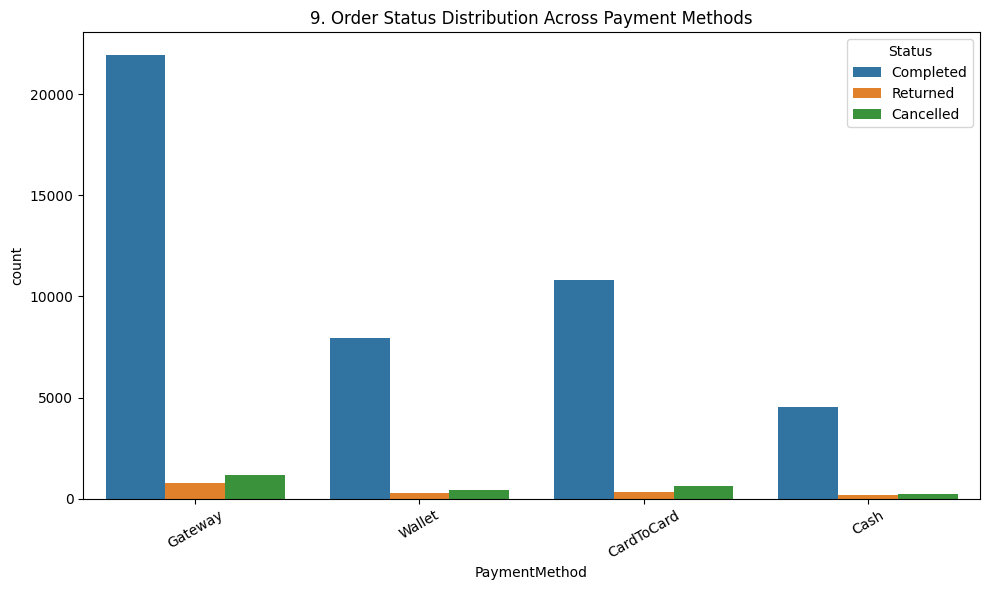

In [24]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='PaymentMethod', hue='Status')
plt.title(f'{plot_no}. Order Status Distribution Across Payment Methods')
plt.xticks(rotation=30)
show_fig()
plot_no += 1

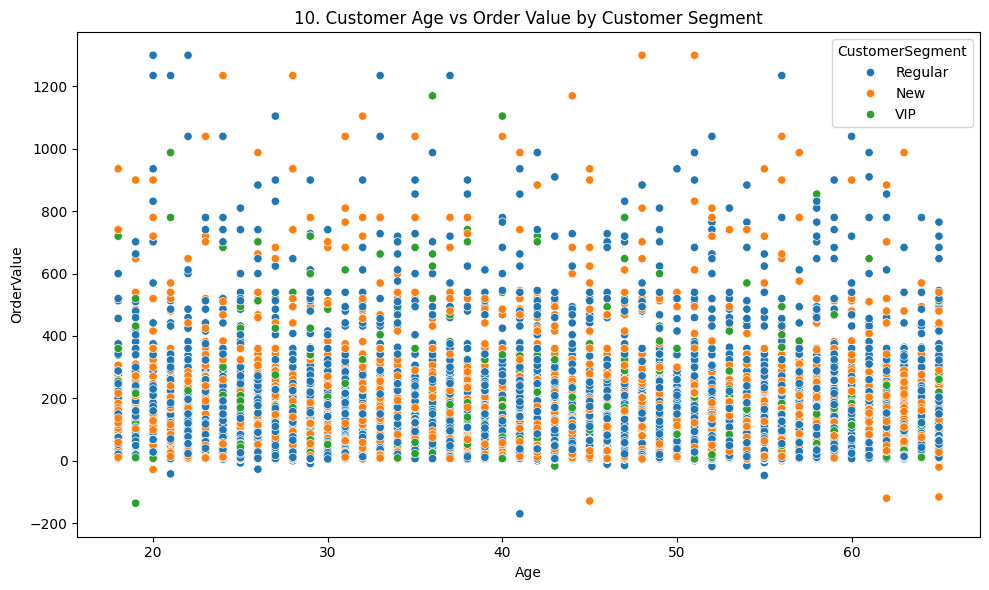

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Age', y='OrderValue', hue='CustomerSegment')
plt.title(f'{plot_no}. Customer Age vs Order Value by Customer Segment')
show_fig()
plot_no += 1

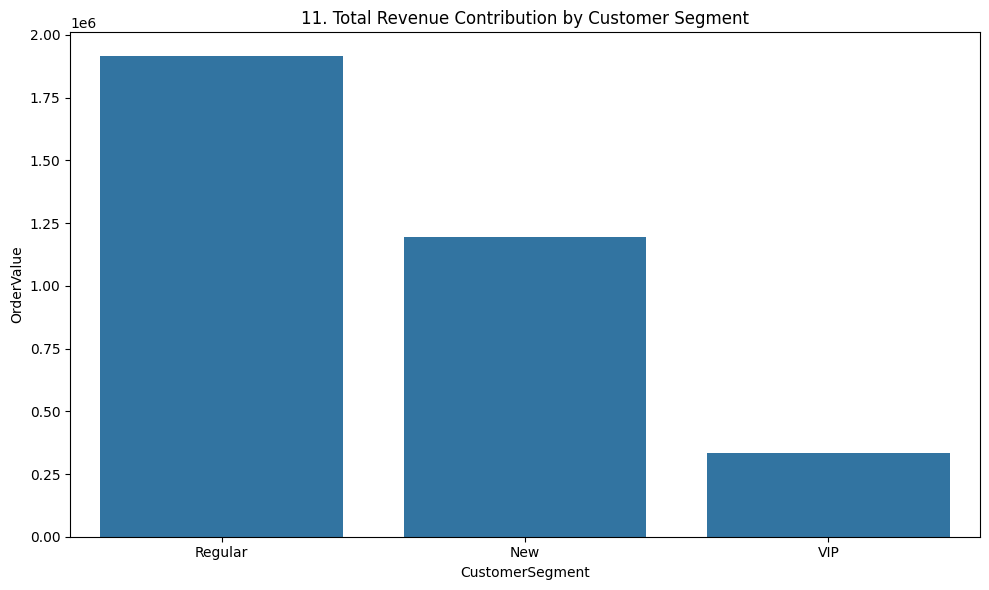

In [26]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='CustomerSegment', y='OrderValue', estimator='sum', errorbar=None)
plt.title(f'{plot_no}. Total Revenue Contribution by Customer Segment')
show_fig()
plot_no += 1

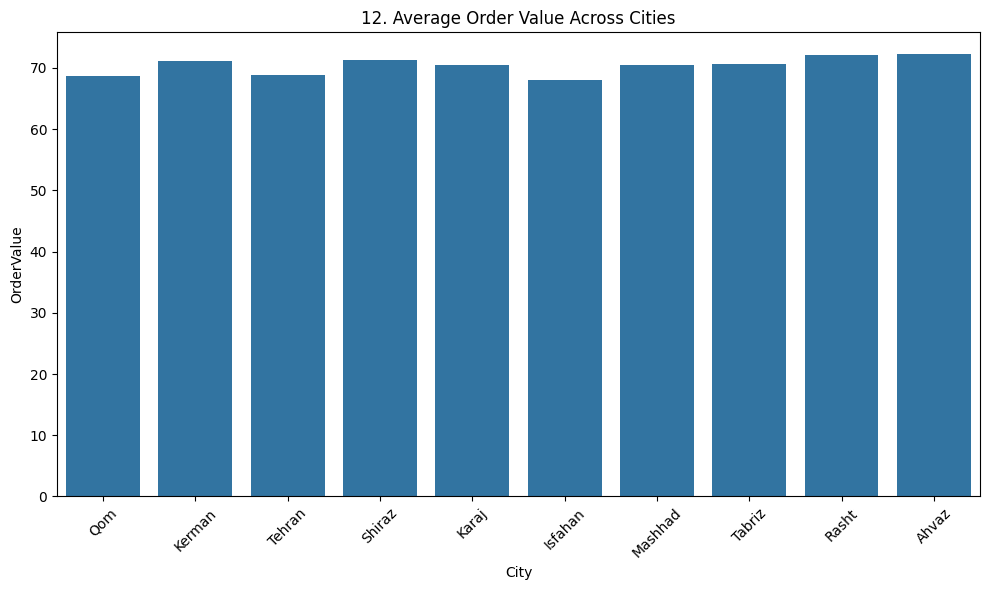

In [27]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='City', y='OrderValue', estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Average Order Value Across Cities')
plt.xticks(rotation=45)
show_fig()
plot_no += 1

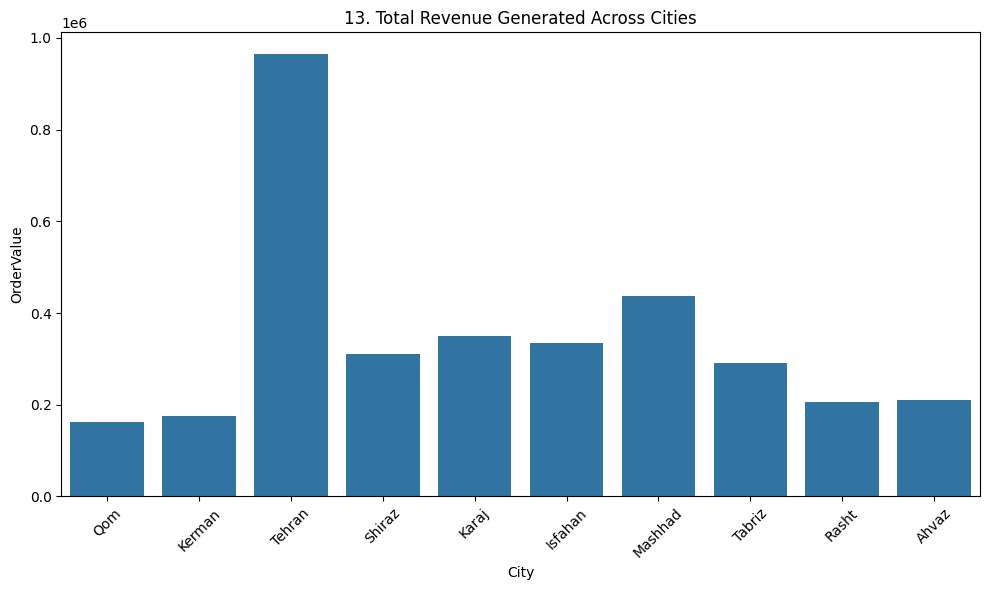

In [28]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='City', y='OrderValue', estimator='sum', errorbar=None)
plt.title(f'{plot_no}. Total Revenue Generated Across Cities')
plt.xticks(rotation=45)
show_fig()
plot_no += 1

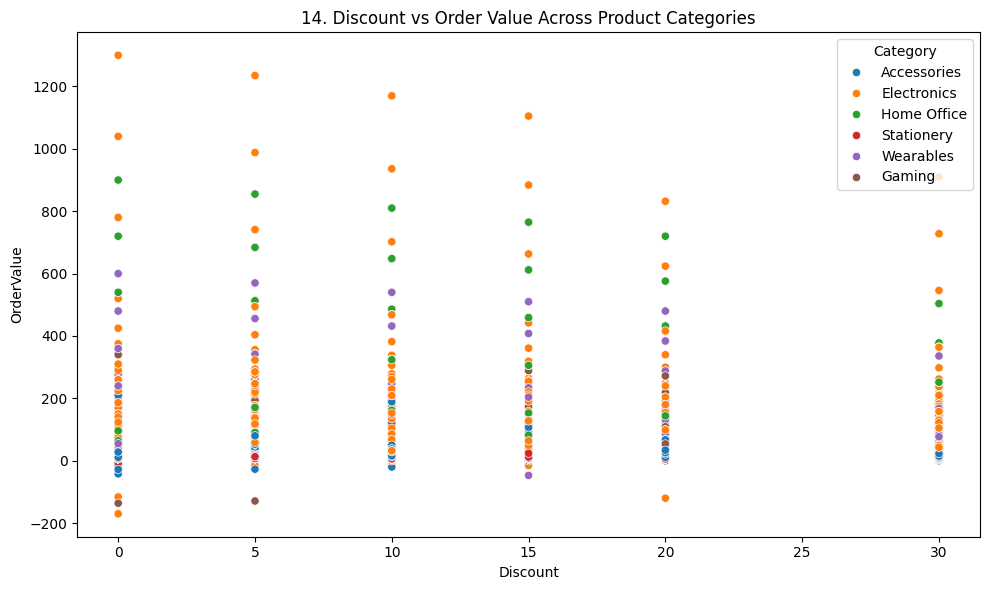

In [29]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Discount', y='OrderValue', hue='Category')
plt.title(f'{plot_no}. Discount vs Order Value Across Product Categories')
show_fig()
plot_no += 1

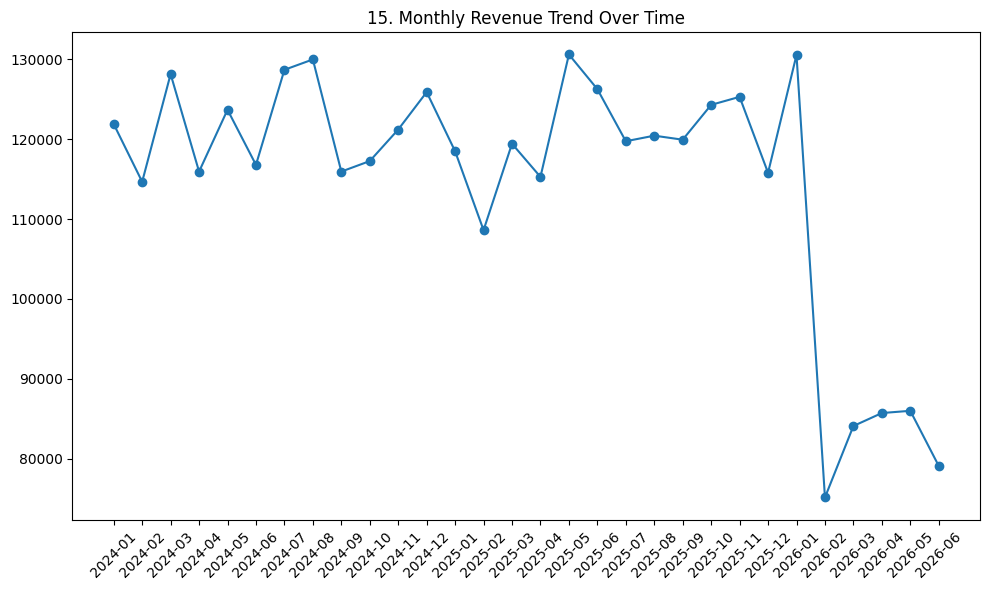

In [30]:
fig = plt.figure(figsize=(10,6))
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
monthly_sales = df.groupby(df['OrderDate'].dt.to_period('M'))['OrderValue'].sum()
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o')
plt.title(f'{plot_no}. Monthly Revenue Trend Over Time')
plt.xticks(rotation=45)
show_fig()
plot_no += 1

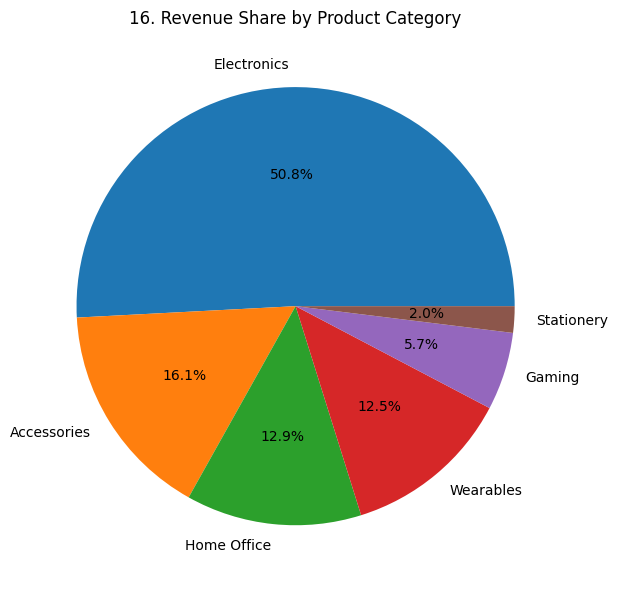

In [31]:
fig = plt.figure(figsize=(10,6))
category_sales = df.groupby('Category')['OrderValue'].sum().sort_values(ascending=False)
plt.pie(category_sales.values, labels=category_sales.index, autopct='%1.1f%%')
plt.title(f'{plot_no}. Revenue Share by Product Category')
show_fig()
plot_no += 1

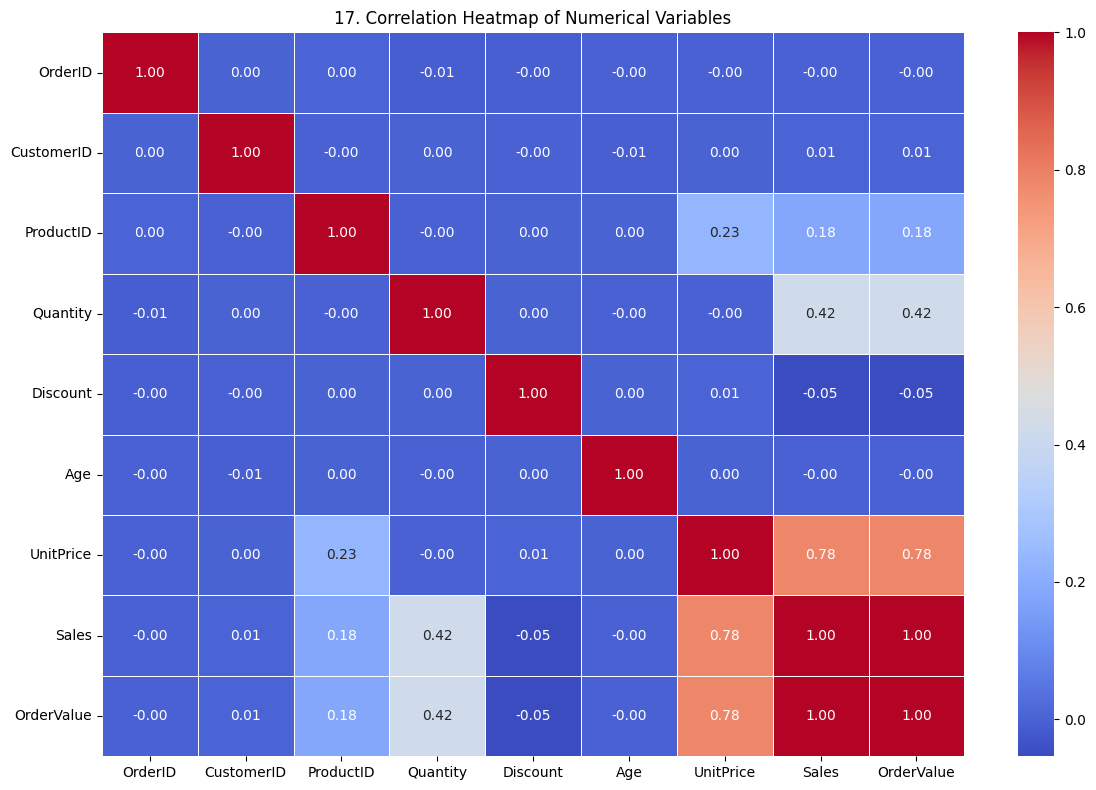

In [32]:
fig = plt.figure(figsize=(12,8))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Variables')
show_fig()
plot_no += 1

# Model Training

## Create features and target

In [33]:
X = df.drop(columns=['OrderValue']).copy()
y = df['OrderValue'].copy()

## Extract useful information from date columns

In [34]:
for col in ['OrderDate', 'SignupDate']:
    X[col] = pd.to_datetime(X[col], errors='coerce')
    X[col + '_Year'] = X[col].dt.year
    X[col + '_Month'] = X[col].dt.month
    X[col + '_Day'] = X[col].dt.day
    X[col + '_DayOfWeek'] = X[col].dt.dayofweek
    X.drop(columns=[col], inplace=True)

## Remove identifier columns

In [35]:
X.drop(columns=['OrderID', 'CustomerID', 'ProductID'], errors='ignore', inplace=True)

## Identify numerical and categorical features

In [36]:
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

## Preprocess numerical and categorical features

In [37]:
preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

## Split data into training and testing sets

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

## Build a powerful regression model

In [39]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', ExtraTreesRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=1.0,
        n_jobs=-1,
        random_state=42
    ))
])

## Train the model

In [40]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  Index(['Quantity', 'Discount', 'Age', 'UnitPrice', 'Sales', 'OrderDate_Year',
       'OrderDate_Month', 'OrderDate_Day', 'OrderDate_DayOfWeek',
       'SignupDate_Year', 'SignupDate_Month', 'SignupDate_Day',
       'SignupDate_DayOfWeek'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['PaymentMethod', 'Status', 'City', 'CustomerSegment', 'ProductName',
       'Category'],
      dtype='object'))])),
                ('regressor',
                 ExtraTreesRegressor(n_estimators=300, n_jobs=-1,
                                     random_state=42))])

## Generate predictions

In [41]:
y_pred = model.predict(X_test)

## Calculate regression performance

In [42]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.2%}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

R² Score: 99.96%
MAE: 0.04
RMSE: 1.76


## Plot actual vs predicted values

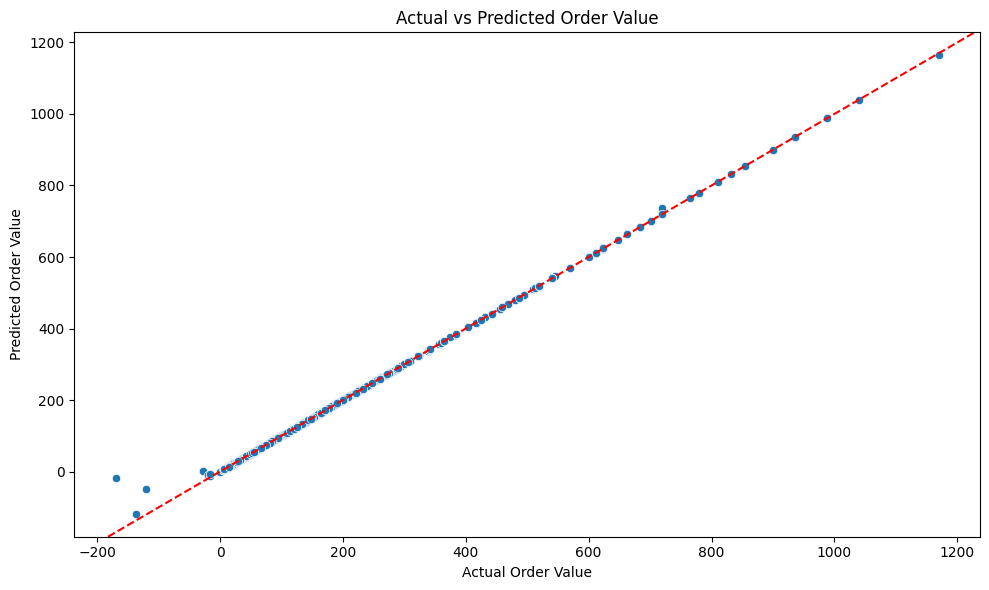

In [43]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual Order Value')
plt.ylabel('Predicted Order Value')
plt.title('Actual vs Predicted Order Value')
plt.axline((0, 0), slope=1, color='red', linestyle='--')
show_fig()
plot_no += 1

###E-Commerce Sales Data Analysis